In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../3/train.csv', usecols = ['PassengerId', 'Survived', 'Pclass', 'Age'])

In [4]:
df.head()

,PassengerId,Survived,Pclass,Age
0,1,0,3,22.0
1,2,1,1,38.0
2,3,1,3,26.0
3,4,1,1,35.0
4,5,0,3,35.0


<Axes: xlabel='Age', ylabel='Count'>

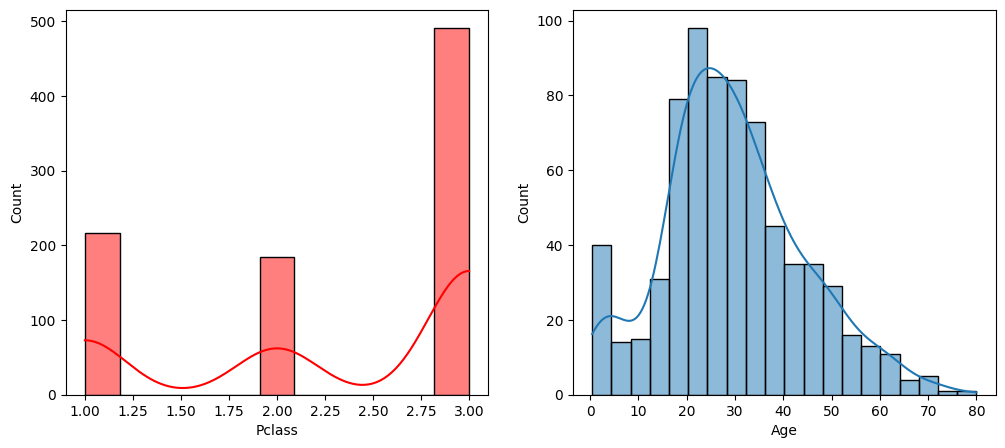

In [5]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Pclass'], kde=True, color = 'Red')

plt.subplot(1, 2, 2)
sns.histplot(df['Age'], kde=True)

In [6]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: xlabel='Age'>

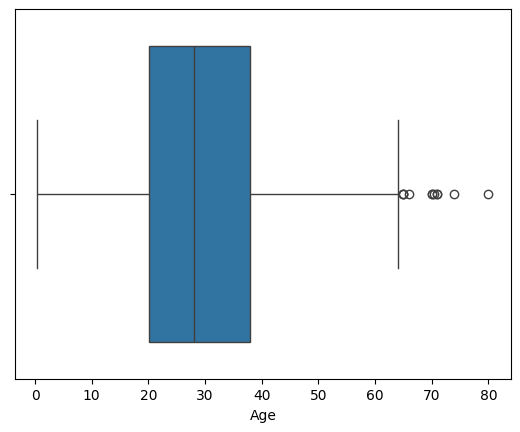

In [7]:
sns.boxplot(df['Age'], orient='h')   # H -> Horizontal

In [8]:
# Finding the IQR

Q1 = df['PassengerId'].quantile(0.25)
Q3 = df['PassengerId'].quantile(0.75)
IQR = Q3 - Q1

In [9]:
Q1

np.float64(223.5)

In [10]:
Q3

np.float64(668.5)

In [11]:
IQR

np.float64(445.0)

In [12]:
Upper_Limit = Q3 + (1.5 * IQR)
Lower_Limit = Q1 - (1.5 * IQR)

In [13]:
Upper_Limit

np.float64(1336.0)

In [14]:
Lower_Limit

np.float64(-444.0)

# Finding Outliers

In [15]:
df[df['PassengerId'] > Upper_Limit]

,PassengerId,Survived,Pclass,Age


In [16]:
df[df['Survived'] < Lower_Limit]

,PassengerId,Survived,Pclass,Age


# Trimming

In [17]:
new_df = df[df['PassengerId'] < Upper_Limit]

In [18]:
new_df.shape

(891, 4)

C:\Users\harsh\AppData\Local\Temp\ipykernel_15976\532418737.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['PassengerId'])
C:\Users\harsh\AppData\Local\Temp\ipykernel_15976\532418737.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['PassengerId'])


<Axes: ylabel='PassengerId'>

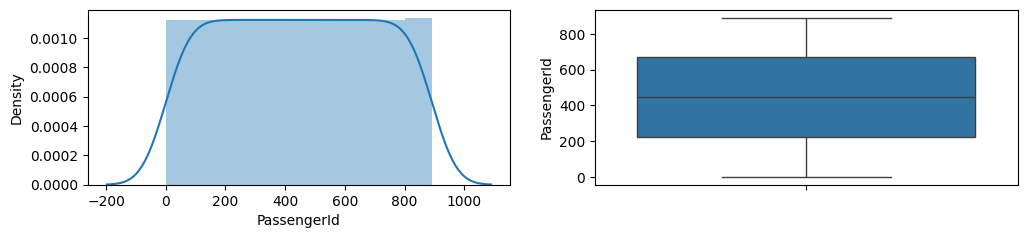

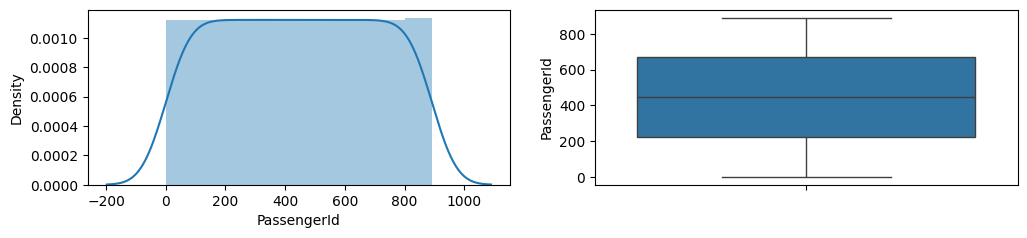

In [ ]:
# Comparing

plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 1)    # row, col, poition
sns.distplot(df['PassengerId'])

plt.subplot(2, 2, 2)
sns.boxplot(df['PassengerId'])

plt.figure(figsize=(12, 5))
plt.subplot(2, 2, 3)
sns.distplot(new_df['PassengerId'])

plt.subplot(2, 2, 4)
sns.boxplot(new_df['PassengerId'])


# 2 rows
# 2 columns
# Total boxes = 2 × 2 = 4

# +---------+---------+
# |    1    |    2    |
# +---------+---------+
# |    3    |    4    |
# +---------+---------+

# Capping

In [28]:
new_df_cap = df.copy()

In [29]:
new_df_cap['PassengerId'] = np.where(
    new_df_cap['PassengerId'] > Upper_Limit, 
    Upper_Limit,
    np.where(
        new_df_cap['PassengerId'] < Lower_Limit, 
        Lower_Limit, 
        new_df_cap['PassengerId']
    ) 
)

In [34]:
new_df_cap.shape

(891, 4)

C:\Users\harsh\AppData\Local\Temp\ipykernel_15976\1116326698.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Pclass'])
C:\Users\harsh\AppData\Local\Temp\ipykernel_15976\1116326698.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['Pclass'])


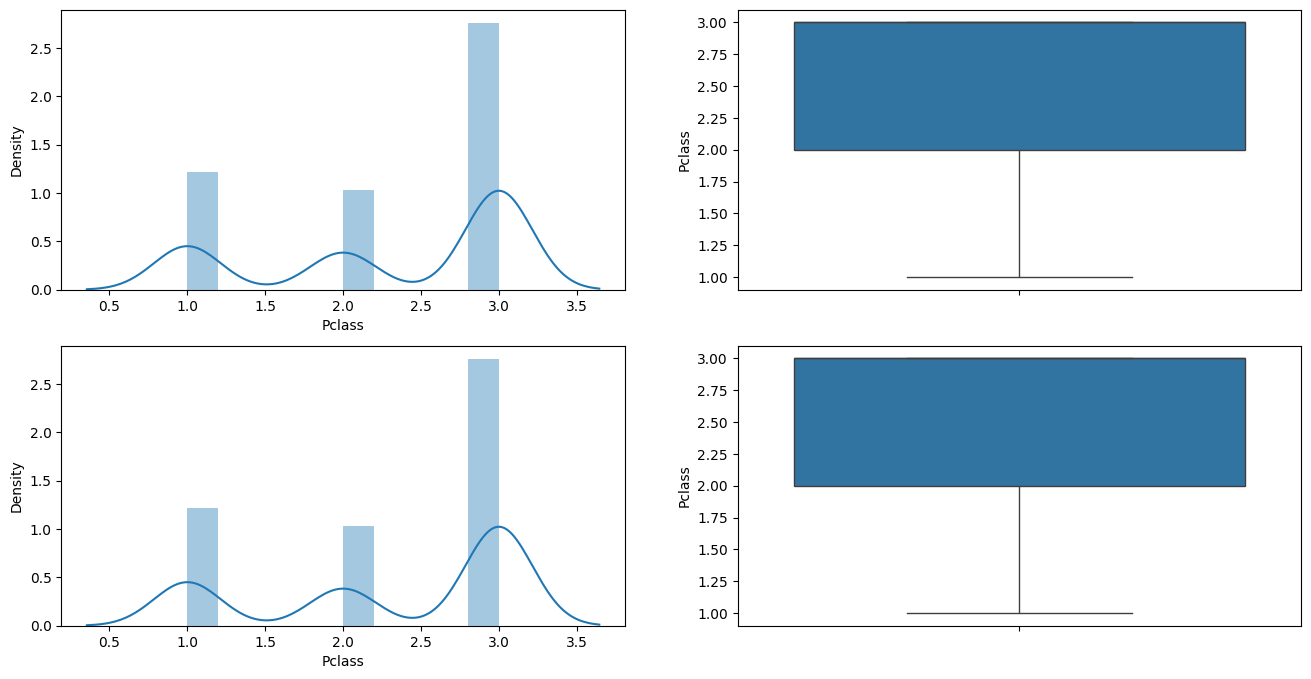

In [36]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['Pclass'])

plt.subplot(2,2,2)
sns.boxplot(df['Pclass'])

plt.subplot(2,2,3)
sns.distplot(new_df_cap['Pclass'])

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['Pclass'])

plt.show()